<a href="https://colab.research.google.com/github/talhanoor23/algorithmic-trading/blob/main/Indicators.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install --upgrade pip
!pip uninstall -y numpy pandas_ta
!pip install numpy==1.24.3 pandas_ta

In [ ]:
!pip install yfinance pandas_datareader

In [ ]:
from statsmodels.regression.rolling import RollingOLS
import pandas as pd
import pandas_ta as ta
import yfinance as yf
import pandas_datareader.data as pdr
import matplotlib.pyplot as plt
import statsmodels.api as sm
import datetime as dt
import warnings
warnings.filterwarnings('ignore')

In [ ]:
import pandas_ta as ta

In [ ]:
# df = pd.DataFrame()
import yfinance as yf
df = yf.download("BTC-USD", start="2023-01-01", end="2024-01-01")

[*********************100%***********************]  1 of 1 completed


In [ ]:
# Convert column names to lowercase and flatten MultiIndex if it exists
if isinstance(df.columns, pd.MultiIndex):
    # Flatten the MultiIndex using the first level (price type) and convert to lowercase
    df.columns = [col[0].lower() for col in df.columns]
else:
    # Otherwise, convert the Index to lowercase
    df.columns = df.columns.str.lower()

# Calculate some common technical indicators and assign to new columns
df['SMA_20'] = df.ta.sma(length=20)
df['RSI_14'] = df.ta.rsi(length=14)
macd_results = df.ta.macd()
df['MACD_12_26_9'] = macd_results['MACD_12_26_9']
df['MACDh_12_26_9'] = macd_results['MACDh_12_26_9']
df['MACDs_12_26_9'] = macd_results['MACDs_12_26_9']


# Display the DataFrame with new indicators
display(df.tail())

,close,high,low,open,volume,SMA_20,RSI_14,MACD_12_26_9,MACDh_12_26_9,MACDs_12_26_9
Date,,,,,,,,,,
2023-12-27,43442.855469,43683.160156,42167.582031,42518.468750,25260941032,42928.051172,57.563288,945.599611,-195.627117,1141.226728
2023-12-28,42627.855469,43804.781250,42318.550781,43468.199219,22992093014,42851.113867,52.971739,841.965503,-239.408980,1081.374483
2023-12-29,42099.402344,43124.324219,41424.062500,42614.644531,26000021055,42769.784766,50.176936,709.019835,-297.883718,1006.903553
2023-12-30,42156.902344,42584.125000,41556.226562,42091.753906,16013925945,42688.644922,50.483066,601.367020,-324.429226,925.796247
2023-12-31,42265.187500,42860.937500,41998.253906,42152.097656,16397498810,42739.712695,51.092516,518.808594,-325.590122,844.398716


In [ ]:
print(df.columns)

Index(['close', 'high', 'low', 'open', 'volume', 'SMA_20', 'RSI_14',
       'MACD_12_26_9', 'MACDh_12_26_9', 'MACDs_12_26_9'],
      dtype='object')


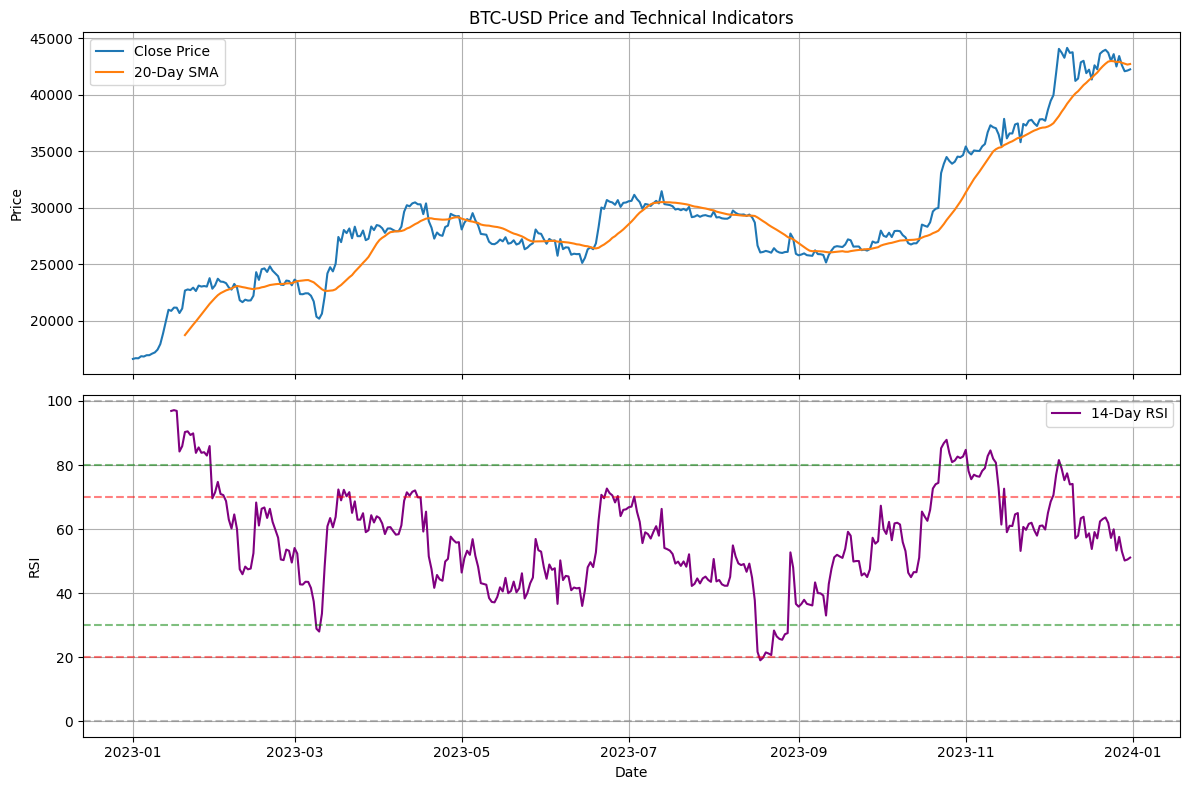

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(12, 8), sharex=True)

# Plotting Price and SMA
axes[0].plot(df.index, df['close'], label='Close Price')
axes[0].plot(df.index, df['SMA_20'], label='20-Day SMA')
axes[0].set_ylabel('Price')
axes[0].set_title('BTC-USD Price and Technical Indicators')
axes[0].legend()
axes[0].grid(True)

# Plotting RSI
axes[1].plot(df.index, df['RSI_14'], label='14-Day RSI', color='purple')
axes[1].axhline(0, linestyle='--', alpha=0.5, color='gray')
axes[1].axhline(20, linestyle='--', alpha=0.5, color='red')
axes[1].axhline(30, linestyle='--', alpha=0.5, color='green')
axes[1].axhline(70, linestyle='--', alpha=0.5, color='red')
axes[1].axhline(80, linestyle='--', alpha=0.5, color='green')
axes[1].axhline(100, linestyle='--', alpha=0.5, color='gray')
axes[1].set_ylabel('RSI')
axes[1].set_xlabel('Date')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

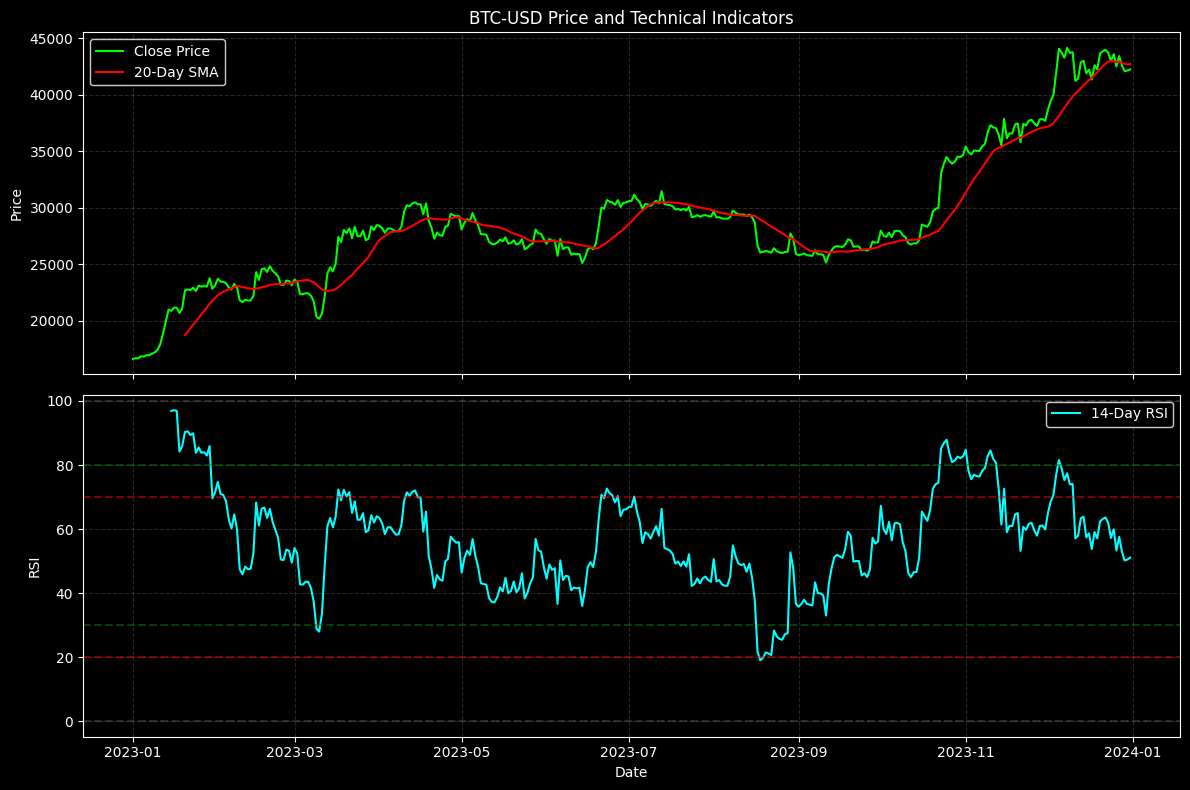

In [ ]:
import matplotlib.pyplot as plt

# Set dark background for the whole plot
plt.style.use('dark_background')  # Optional global style

fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(12, 8), sharex=True)

# Set black background for both subplots
for ax in axes:
    ax.set_facecolor('black')
    ax.tick_params(colors='white')  # White tick labels
    ax.yaxis.label.set_color('white')  # White y-label
    ax.xaxis.label.set_color('white')  # White x-label
    ax.title.set_color('white')       # White title
    ax.grid(True, color='gray', linestyle='--', alpha=0.3)  # Soft grid

# Plotting Price and SMA
axes[0].plot(df.index, df['close'], label='Close Price', color='lime')   # Green
axes[0].plot(df.index, df['SMA_20'], label='20-Day SMA', color='red')    # Red
axes[0].set_title('BTC-USD Price and Technical Indicators')
axes[0].legend(facecolor='black', edgecolor='white', labelcolor='white')

# Plotting RSI
axes[1].plot(df.index, df['RSI_14'], label='14-Day RSI', color='cyan')  # Custom color
axes[1].axhline(0, linestyle='--', alpha=0.3, color='gray')
axes[1].axhline(20, linestyle='--', alpha=0.5, color='red')
axes[1].axhline(30, linestyle='--', alpha=0.5, color='green')
axes[1].axhline(70, linestyle='--', alpha=0.5, color='red')
axes[1].axhline(80, linestyle='--', alpha=0.5, color='green')
axes[1].axhline(100, linestyle='--', alpha=0.3, color='gray')
axes[1].set_ylabel('RSI')
axes[1].set_xlabel('Date')
axes[1].legend(facecolor='black', edgecolor='white', labelcolor='white')

plt.tight_layout()
plt.show()

In [ ]:
df.ta.log_return(cumulative=True, append=True)
df

,close,high,low,open,volume,SMA_20,RSI_14,MACD_12_26_9,MACDh_12_26_9,MACDs_12_26_9,CUMLOGRET_1
Date,,,,,,,,,,,
2023-01-01,16625.080078,16630.439453,16521.234375,16547.914062,9244361700,NaN,NaN,NaN,NaN,NaN,0.000000
2023-01-02,16688.470703,16759.343750,16572.228516,16625.509766,12097775227,NaN,NaN,NaN,NaN,NaN,0.003806
2023-01-03,16679.857422,16760.447266,16622.371094,16688.847656,13903079207,NaN,NaN,NaN,NaN,NaN,0.003289
2023-01-04,16863.238281,16964.585938,16667.763672,16680.205078,18421743322,NaN,NaN,NaN,NaN,NaN,0.014224
2023-01-05,16836.736328,16884.021484,16790.283203,16863.472656,13692758566,NaN,NaN,NaN,NaN,NaN,0.012651
...,...,...,...,...,...,...,...,...,...,...,...
2023-12-27,43442.855469,43683.160156,42167.582031,42518.468750,25260941032,42928.051172,57.563288,945.599611,-195.627117,1141.226728,0.960534
2023-12-28,42627.855469,43804.781250,42318.550781,43468.199219,22992093014,42851.113867,52.971739,841.965503,-239.408980,1081.374483,0.941596
2023-12-29,42099.402344,43124.324219,41424.062500,42614.644531,26000021055,42769.784766,50.176936,709.019835,-297.883718,1006.903553,0.929121


In [ ]:
ind_list = df.ta.indicators(as_list=True)
print(ind_list)

['aberration', 'above', 'above_value', 'accbands', 'ad', 'adosc', 'adx', 'alma', 'amat', 'ao', 'aobv', 'apo', 'aroon', 'atr', 'bbands', 'below', 'below_value', 'bias', 'bop', 'brar', 'cci', 'cdl_pattern', 'cdl_z', 'cfo', 'cg', 'chop', 'cksp', 'cmf', 'cmo', 'coppock', 'cross', 'cross_value', 'cti', 'decay', 'decreasing', 'dema', 'dm', 'donchian', 'dpo', 'ebsw', 'efi', 'ema', 'entropy', 'eom', 'er', 'eri', 'fisher', 'fwma', 'ha', 'hilo', 'hl2', 'hlc3', 'hma', 'hwc', 'hwma', 'ichimoku', 'increasing', 'inertia', 'jma', 'kama', 'kc', 'kdj', 'kst', 'kurtosis', 'kvo', 'linreg', 'log_return', 'long_run', 'macd', 'mad', 'massi', 'mcgd', 'median', 'mfi', 'midpoint', 'midprice', 'mom', 'natr', 'nvi', 'obv', 'ohlc4', 'pdist', 'percent_return', 'pgo', 'ppo', 'psar', 'psl', 'pvi', 'pvo', 'pvol', 'pvr', 'pvt', 'pwma', 'qqe', 'qstick', 'quantile', 'rma', 'roc', 'rsi', 'rsx', 'rvgi', 'rvi', 'short_run', 'sinwma', 'skew', 'slope', 'sma', 'smi', 'squeeze', 'squeeze_pro', 'ssf', 'stc', 'stdev', 'stoch', '

Strategies and types of strategies

In [ ]:
MyStrategy = ta.Strategy(
    name="DCSMA10",
    ta=[
        {"kind": "ohlc4"},
        {"kind": "sma", "length": 10, "col_names":("SMA",)},
        {"kind": "donchian", "lower_length": 10, "upper_length": 15, "col_names":("DLC","DCM","DCU")},
        {"kind": "ema", "close": "OHLC4", "length": 10, "suffix": "OHLC4", "col_names":("EMA2",)},
    ]
)

# (2) Run the Strategy
df.ta.strategy(MyStrategy, length= 20)
df

,close,high,low,open,volume,SMA_20,RSI_14,MACD_12_26_9,MACDh_12_26_9,MACDs_12_26_9,CUMLOGRET_1,OHLC4,SMA,DLC,DCM,DCU,EMA2
Date,,,,,,,,,,,,,,,,,
2023-01-01,16625.080078,16630.439453,16521.234375,16547.914062,9244361700,NaN,NaN,NaN,NaN,NaN,0.000000,16581.166992,NaN,NaN,NaN,NaN,NaN
2023-01-02,16688.470703,16759.343750,16572.228516,16625.509766,12097775227,NaN,NaN,NaN,NaN,NaN,0.003806,16661.388184,NaN,NaN,NaN,NaN,NaN
2023-01-03,16679.857422,16760.447266,16622.371094,16688.847656,13903079207,NaN,NaN,NaN,NaN,NaN,0.003289,16687.880859,NaN,NaN,NaN,NaN,NaN
2023-01-04,16863.238281,16964.585938,16667.763672,16680.205078,18421743322,NaN,NaN,NaN,NaN,NaN,0.014224,16793.948242,NaN,NaN,NaN,NaN,NaN
2023-01-05,16836.736328,16884.021484,16790.283203,16863.472656,13692758566,NaN,NaN,NaN,NaN,NaN,0.012651,16843.628418,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-27,43442.855469,43683.160156,42167.582031,42518.468750,25260941032,42928.051172,57.563288,945.599611,-195.627117,1141.226728,0.960534,42953.016602,42928.051172,40530.257812,42449.107422,44367.957031,42488.742151
2023-12-28,42627.855469,43804.781250,42318.550781,43468.199219,22992093014,42851.113867,52.971739,841.965503,-239.408980,1081.374483,0.941596,43054.846680,42851.113867,41676.488281,43022.222656,44367.957031,42542.656868
2023-12-29,42099.402344,43124.324219,41424.062500,42614.644531,26000021055,42769.784766,50.176936,709.019835,-297.883718,1006.903553,0.929121,42315.608398,42769.784766,41424.062500,42896.009766,44367.957031,42521.033204


In [ ]:
df.ta.categories

['candles',
 'cycles',
 'momentum',
 'overlap',
 'performance',
 'statistics',
 'trend',
 'volatility',
 'volume']

In [ ]:
df.ta.strategy('Momentum')

39it [00:00, 81.67it/s]


In [ ]:
df

,close,high,low,open,volume,SMA_20,RSI_14,MACD_12_26_9,MACDh_12_26_9,MACDs_12_26_9,...,STOCHk_14_3_3,STOCHd_14_3_3,STOCHRSIk_14_14_3_3,STOCHRSId_14_14_3_3,TRIX_30_9,TRIXs_30_9,TSI_13_25_13,TSIs_13_25_13,UO_7_14_28,WILLR_14
Date,,,,,,,,,,,,,,,,,,,,,
2023-01-01,16625.080078,16630.439453,16521.234375,16547.914062,9244361700,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-01-02,16688.470703,16759.343750,16572.228516,16625.509766,12097775227,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-01-03,16679.857422,16760.447266,16622.371094,16688.847656,13903079207,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-01-04,16863.238281,16964.585938,16667.763672,16680.205078,18421743322,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-01-05,16836.736328,16884.021484,16790.283203,16863.472656,13692758566,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-27,43442.855469,43683.160156,42167.582031,42518.468750,25260941032,42928.051172,57.563288,945.599611,-195.627117,1141.226728,...,69.361220,71.110023,33.811680,36.886067,0.527300,0.547737,18.856996,24.175162,57.704911,-24.105630
2023-12-28,42627.855469,43804.781250,42318.550781,43468.199219,22992093014,42851.113867,52.971739,841.965503,-239.408980,1081.374483,...,60.803270,65.553035,13.471902,26.348844,0.519723,0.542848,16.804452,23.122203,52.550641,-45.342312
2023-12-29,42099.402344,43124.324219,41424.062500,42614.644531,26000021055,42769.784766,50.176936,709.019835,-297.883718,1006.903553,...,57.146565,62.437018,13.471902,20.251828,0.510898,0.537379,14.242379,21.853657,51.087813,-59.112363


In [ ]:
df.ta.strategy()

In [ ]:
df.ta.strategy(category='Momentum')